In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from scipy.stats import kruskal

def epsilon_squared_fast(df, cat_col, num_col):
    """
    Максимально простая версия — только число ε²
    """

    groups = [group[num_col].values for name, group in df.groupby(cat_col)]
    h_stat, _ = kruskal(*groups)
    n = len(df)
    k = len(groups)

    return max(0, (h_stat - (k - 1)) / (n - 1))

## Подготовка данных

In [3]:
import pandas as pd
import numpy as np
import math
import time
import os
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.float_format', '{:.2f}'.format)

In [4]:
shot_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/диплом 2026/db_dvt_data.csv', header=0, index_col=0)
frames_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/диплом 2026/db_frames.csv', header=0)
metadata_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/диплом 2026/db_metadata.csv', header=0, index_col=0)

In [5]:
metadata_df['released'] = pd.to_datetime(metadata_df['released'])
metadata_df['month'] = metadata_df['released'].dt.month
metadata_df['screen_ratio'] = metadata_df['height'] / metadata_df['width']

shot_df['timecode'] = pd.to_datetime(shot_df['timecode'], format='%H:%M:%S').dt.time
# shot_df['time_minute'] = shot_df['timecode']
frames_df = pd.merge(frames_df, shot_df, on=['title', 'shot_index'], how='left')
frames_df = frames_df[frames_df['shot_index'] >= 0]

In [6]:
frames_df.loc[frames_df['nobjects'] > 4200, 'nobjects'] = np.nan

In [7]:
# заменяем значения на пропуски там, где много лиц, т.к. стоит площадь 0
frames_df.loc[frames_df['faces'] > 1, 'fsquare'] = np.nan

In [8]:
frames_df['faces_bool'] = frames_df['faces'].apply(lambda x: 1 if x > 0 else 0)

In [9]:
def closeup_degree(x):
    if x > 0.25:
        return "closeup"
    elif x > 0.10:
        return "medium closeup"
    elif x > 0 or math.isnan(x):
        return 'human'
    else:
        return 'none'

frames_df['closeup'] = frames_df['fsquare'].apply(closeup_degree)

In [10]:
#новый столбец для таймкода
frames_df['frame_time'] = frames_df['nframe'].apply(lambda x: time.strftime('%H:%M:%S', time.gmtime(x/24)))

In [11]:
duplicates = frames_df.duplicated(subset=['title', 'nframe'])

In [12]:
frames_df[duplicates == True]['title'].nunique()

0

In [13]:
frames_df.isna().mean() * 100 # нет пропусков, кроме крупного плана

,0
nframe,0.00
faces,0.00
fsquare,5.88
neyes,0.00
nobjects,0.00
brightness,0.00
shot_index,0.00
title,0.00
start,0.00
end,0.00


In [14]:
metadata_df.sample(2)

,title,year,genre,eng_title,rus_title,height,width,frame_count,shot_count,film_start,...,rated,released,runtime,genres,directors,writers,actors,awards,month,screen_ratio
index,,,,,,,,,,,,,,,,,,,,,
52,Timebomb,1991,sci-fi,Timebomb,Бомба замедленного действия,392,720,130636,1211,1302,...,R,1991-05-25,96,"Action, Drama, Sci-Fi",Avi Nesher,Avi Nesher,"Michael Biehn, Patsy Kensit, Tracy Scoggins",2 wins & 1 nomination,5,0.54
42,Daughters_of_the_Dust,1991,history,Daughters of the Dust,Дочери пыли,384,720,156563,725,806,...,TV-PG,1991-12-27,113,"Drama, History, Romance",Julie Dash,Julie Dash,"Cora Lee Day, Alva Rogers, Barbara O",4 wins & 2 nominations,12,0.53


In [15]:
shot_df.sample(2)

,title,shot_index,start,end,length,time_length,timecode,part,part_of_6,part_of_9
id,,,,,,,,,,
219491,Patriot_Games,743,106663,106832,169,7.04,01:14:04,2,4,6
331683,The_People_Under_the_Stairs,547,68337,68473,136,5.67,00:47:27,2,3,5


In [16]:
frames_df.sample(2)

,nframe,faces,fsquare,neyes,nobjects,brightness,shot_index,title,start,end,length,time_length,timecode,part,part_of_6,part_of_9,faces_bool,closeup,frame_time
1705034,129552,2,NaN,1,144.00,55.39,1397,Blade,129494.00,129580.00,86.00,3.58,01:29:55,3.00,5.00,8.00,1,human,01:29:58
1430468,20448,0,0.00,0,7.00,9.80,120,Bound,19885.00,20453.00,568.00,23.67,00:13:48,1.00,1.00,2.00,0,none,00:14:12


In [17]:
shot_df_meta = pd.merge(shot_df, metadata_df[['title', 'year', 'genre']], on=['title'], how='left')

In [18]:
def names_correlation(kind, data_list, feature):
    sorted_list = []

    for i in data_list:
        films = metadata_df[metadata_df[kind].str.contains(i)]
        sorted_list.append((float(round(films[feature].mean(), 2)), i))

    print(*sorted(sorted_list), sep='\n')

In [19]:
genres_all = list(set(metadata_df['genres'].str.cat(sep=", ").split(', ')))
genres = []

for g in genres_all:
    share = round(metadata_df[metadata_df['genres'].str.contains(g)].shape[0]/298*100, 2)
    if share > 5:
        genres.append(g)

In [20]:
directors_all = list(set(metadata_df['directors'].str.cat(sep=", ").split(', ')))
directors = []

for d in directors_all:
    num = metadata_df[metadata_df['directors'].str.contains(d)].shape[0]
    if num > 2:
        directors.append(d)

In [21]:
writers_all = list(set(metadata_df['writers'].str.cat(sep=", ").split(', ')))
writers = []

for w in writers_all:
    num = metadata_df[metadata_df['writers'].str.contains(w)].shape[0]
    if num > 2:
        writers.append(w)

In [22]:
actors_all = list(set(metadata_df['actors'].str.cat(sep=", ").split(', ')))
actors = []

for a in actors_all:
    num = metadata_df[metadata_df['actors'].str.contains(a)].shape[0]
    if num > 3:
        actors.append(a)

In [23]:
len(actors)

38

In [24]:
metadata_df['mean_scene'] = metadata_df['title'].apply(lambda x: shot_df[shot_df['title'] == x]['length'].mean()/24)
metadata_df['median_scene'] = metadata_df['title'].apply(lambda x: shot_df[shot_df['title'] == x]['length'].median()/24)

In [25]:
for feature in ['faces_bool', 'fsquare', 'nobjects', 'brightness']:
    metadata_df[feature] = metadata_df['title'].apply(lambda x: frames_df[frames_df['title'] == x][feature].mean())
    #metadata_df.plot(kind='scatter', x='runtime', y=feature)

In [26]:
def add_closeup_data(title):
    df = frames_df[frames_df['title'] == title]
    data = df['closeup'].value_counts()
    data_sum = df['closeup'].count()
    none = data['none']
    human = data['human']
    medium = data['medium closeup']
    if 'closeup' in data:
        close = data['closeup']
    else:
        close = 0
    return pd.Series({
        'cu_none': none/data_sum,
        'cu_human': human/data_sum,
        'cu_medium': medium/data_sum,
        'cu_close': close/data_sum,
    })

# Применяем к колонке
metadata_df[['cu_none', 'cu_human', 'cu_medium', 'cu_close']] = metadata_df['title'].apply(add_closeup_data)
metadata_df['cu'] = metadata_df['cu_medium'] + metadata_df['cu_close']

In [27]:
# среднее по жанрам и актам по различным параметрам
# проблема - я люблю медиану, но для наличия лица нужно именно среднее
def genre_act_correlation(feature, extra_df=frames_df, num=9, mean='median'):

    df = metadata_df.copy()
    if num == 9:
      part_column = 'part_of_9'
    else:
      part_column = 'part'

    if mean == 'median':
      agg_data = extra_df.groupby(['title', part_column])[feature].median().reset_index()
    else:
      agg_data = extra_df.groupby(['title', part_column])[feature].mean().reset_index()

    # Создаем отдельные колонки для каждой части
    for part_num in range(1, num+1):
        part_data = agg_data[agg_data[part_column] == part_num].set_index('title')[feature]
        df[f'part_{part_num}'] = df['title'].map(part_data)

    start_col = 'part_1'
    cols_to_agg = df.columns[df.columns.get_loc(start_col):]
    if mean == 'median':
        result = df.groupby('genre')[cols_to_agg].median()
    else:
        result = df.groupby('genre')[cols_to_agg].mean()

    return result

In [28]:
def part_viz(df, ylabel):
  plt.figure(figsize=(10, 6))
  for category in df.index:
      plt.plot(df.columns, df.loc[category], marker='s', label=category)

  plt.xlabel('Часть фильма')
  plt.ylabel(ylabel)
  # plt.title('Линейный график с несколькими линиями')
  plt.legend()
  plt.xticks(rotation=45)
  plt.grid(True)
  plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
  plt.show()

In [29]:
metadata_df['screen_ratio_wide'] = metadata_df['screen_ratio'].apply(lambda x: 1 if x < 0.5 else 0)

## Попарное сравнение

### Жанры

#### Длительность фильма

In [ ]:
metadata_df.groupby('genre')['runtime'].median().sort_values()

,runtime
genre,
comedy,103.00
horror,106.50
sci-fi,108.50
romance,113.00
war,116.00
thriller,118.00
action,119.00
crime,119.00
history,124.00


In [ ]:
names_correlation('genres', genres, 'runtime')

(105.79, 'Comedy')
(107.46, 'Horror')
(115.62, 'Sci-Fi')
(115.94, 'Mystery')
(116.36, 'Action')
(119.53, 'Thriller')
(120.14, 'Crime')
(120.18, 'Romance')
(120.5, 'Fantasy')
(122.0, 'Adventure')
(124.05, 'Drama')
(135.78, 'War')
(136.76, 'Biography')
(143.83, 'History')


In [ ]:
epsilon_squared_fast(metadata_df, 'genre', 'runtime')

np.float64(0.10208824032386958)

#### Месяц выхода

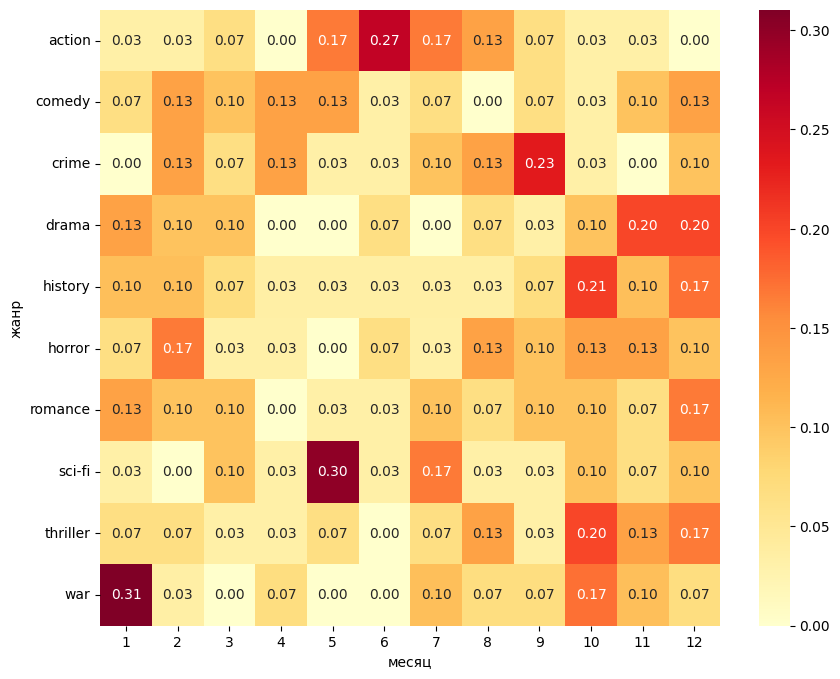

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Создаем таблицу сопряженности с нормализацией по строкам (по x)
crosstab = pd.crosstab(metadata_df['genre'], metadata_df['month'], normalize='index')

# Строим тепловую карту
plt.figure(figsize=(10, 8))
ax = sns.heatmap(crosstab, annot=True, cmap='YlOrRd', fmt='.2f')
#plt.title('Доля вышедших в каждый месяц фильмов по жанрам')
plt.xlabel("месяц")
plt.ylabel("жанр")
ax.tick_params(axis='y', rotation=0)
plt.show()

#### Соотношение экрана

In [ ]:
metadata_df.groupby('genre')['screen_ratio'].median().sort_values()

,screen_ratio
genre,
action,0.42
sci-fi,0.43
horror,0.53
drama,0.53
crime,0.54
war,0.54
comedy,0.54
history,0.55
romance,0.56


In [ ]:
names_correlation('genres', genres, 'screen_ratio')

(0.48, 'Action')
(0.49, 'Adventure')
(0.49, 'Sci-Fi')
(0.5, 'Crime')
(0.5, 'Thriller')
(0.51, 'Biography')
(0.51, 'Fantasy')
(0.52, 'Drama')
(0.52, 'Mystery')
(0.53, 'History')
(0.53, 'War')
(0.54, 'Comedy')
(0.54, 'Horror')
(0.54, 'Romance')


In [ ]:
epsilon_squared_fast(metadata_df, 'genre', 'screen_ratio')

np.float64(0.014950093282746475)

#### оценка

In [ ]:
metadata_df.groupby('genre')['mark'].mean().sort_values()
# микрораздел про то, то вообще-то
# то ли качественные фильмы в некоторых жанрах не так часто выходят, не каждый год,
# то ли что их жестче оценивают

,mark
genre,
war,6.56
sci-fi,6.61
horror,6.62
history,7.02
thriller,7.26
action,7.28
romance,7.42
comedy,7.42
crime,7.60


#### Длительность плана

In [ ]:
epsilon_squared_fast(metadata_df, 'genre', 'mean_scene')

np.float64(0.21968266921226706)

In [ ]:
metadata_df.groupby('genre')['mean_scene'].mean().sort_values()

,mean_scene
genre,
action,4.07
sci-fi,4.40
war,5.52
horror,5.70
history,5.96
comedy,6.22
thriller,6.79
crime,6.92
drama,7.07


In [ ]:
metadata_df.groupby('genre')['median_scene'].median().sort_values()

,median_scene
genre,
action,2.71
sci-fi,2.79
horror,3.08
war,3.21
comedy,3.31
history,3.46
crime,3.48
thriller,3.86
drama,3.98


In [ ]:
names_correlation('genres', genres, 'mean_scene')

(4.19, 'Action')
(4.38, 'Sci-Fi')
(4.57, 'Adventure')
(5.49, 'Mystery')
(5.57, 'War')
(5.59, 'Fantasy')
(5.72, 'Thriller')
(5.77, 'Horror')
(5.89, 'Crime')
(6.38, 'History')
(6.53, 'Biography')
(6.53, 'Drama')
(6.77, 'Comedy')
(7.4, 'Romance')


In [ ]:
metadata_df.groupby('genre')['median_scene'].max().sort_values()

,median_scene
genre,
sci-fi,4.33
action,4.42
war,6.17
history,6.25
comedy,8.33
thriller,9.38
drama,10.08
horror,11.17
romance,15.44


In [ ]:
shot_df_meta.groupby('genre')['time_length'].max().sort_values()

,time_length
genre,
sci-fi,149.96
action,158.33
history,174.62
crime,225.50
thriller,225.92
war,229.25
horror,292.38
romance,332.29
drama,359.12


In [ ]:
genre_shot_act_df = genre_act_correlation('time_length', extra_df=shot_df, num=9).sort_values('part_1')
genre_shot_act_df

,part_1,part_2,part_3,part_4,part_5,part_6,part_7,part_8,part_9
genre,,,,,,,,,
action,2.91,2.86,2.70,2.67,2.81,2.73,2.71,2.52,2.38
sci-fi,3.00,3.05,3.00,3.07,2.94,3.09,3.12,2.49,2.57
comedy,3.17,3.21,3.12,3.28,3.40,3.08,3.68,3.77,3.45
war,3.29,3.44,3.25,3.67,3.54,3.54,3.27,3.35,3.33
history,3.42,3.71,3.77,3.38,3.83,3.71,3.94,3.90,4.00
horror,3.44,3.32,3.31,3.39,3.19,3.17,3.16,3.31,2.56
crime,3.45,3.59,3.58,3.58,3.66,3.50,3.69,3.79,2.92
thriller,3.86,3.77,4.07,4.19,3.85,3.60,3.62,4.04,3.75
drama,4.00,3.96,4.29,4.15,3.88,3.91,3.91,4.17,3.88


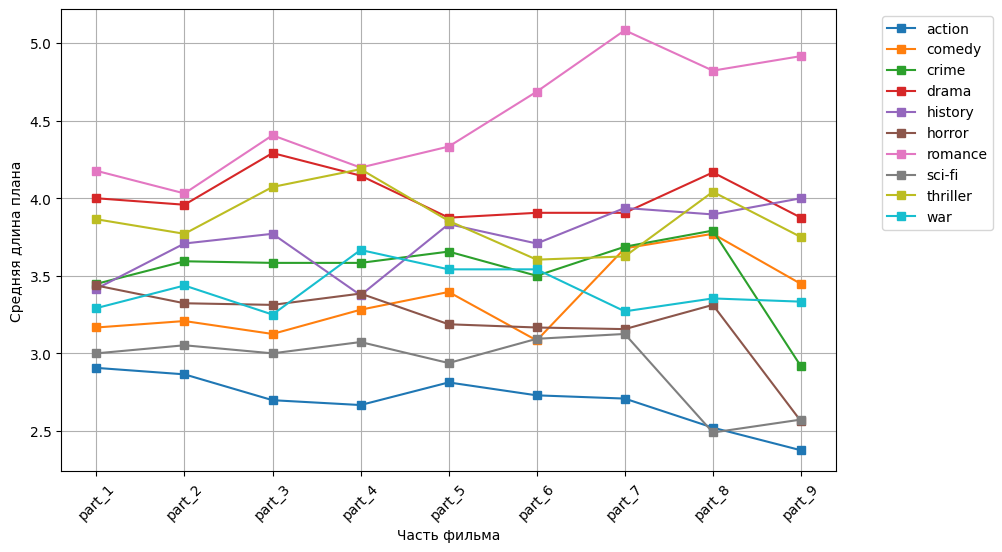

In [ ]:
part_viz(genre_shot_act_df.sort_index(), 'Средняя длина плана')

#### лица

In [ ]:
epsilon_squared_fast(metadata_df, 'genre', 'faces_bool')

np.float64(0.1438857601179127)

In [ ]:
metadata_df.groupby('genre')['faces_bool'].median().sort_values()

,faces_bool
genre,
sci-fi,0.26
action,0.29
war,0.29
horror,0.31
thriller,0.32
history,0.32
crime,0.33
drama,0.37
romance,0.39


In [ ]:
names_correlation('genres', genres, 'faces_bool')

(0.27, 'Sci-Fi')
(0.27, 'War')
(0.29, 'Action')
(0.3, 'Adventure')
(0.31, 'Thriller')
(0.32, 'Crime')
(0.32, 'Horror')
(0.33, 'Mystery')
(0.34, 'Biography')
(0.34, 'Fantasy')
(0.34, 'History')
(0.35, 'Drama')
(0.37, 'Romance')
(0.38, 'Comedy')


In [ ]:
genre_shot_faces_df = genre_act_correlation('faces_bool', num=3, mean='mean').sort_values('part_1')
genre_shot_faces_df

,part_1,part_2,part_3
genre,,,
sci-fi,0.28,0.29,0.27
war,0.29,0.30,0.27
action,0.29,0.30,0.26
thriller,0.31,0.34,0.34
history,0.32,0.36,0.37
crime,0.33,0.34,0.32
horror,0.34,0.34,0.29
drama,0.37,0.39,0.37
comedy,0.38,0.39,0.40


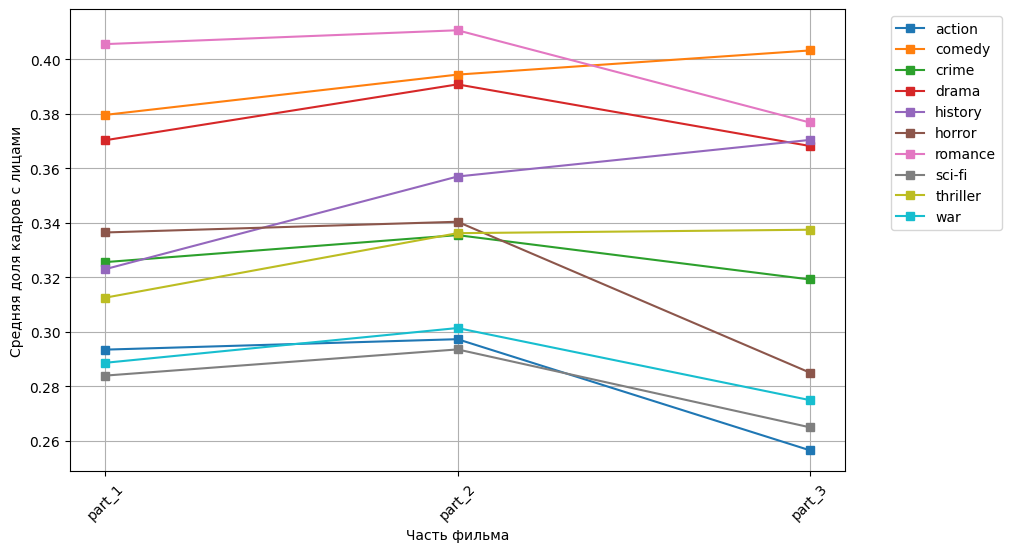

In [ ]:
part_viz(genre_shot_faces_df.sort_index(), 'Средняя доля кадров с лицами')

#### крупный план

In [ ]:
epsilon_squared_fast(metadata_df, 'genre', 'cu_close')

np.float64(0.0468742697004319)

In [ ]:
epsilon_squared_fast(metadata_df, 'genre', 'cu')

np.float64(0.015863250511027813)

In [ ]:
metadata_df.groupby('genre')['cu_none'].mean().sort_values()

,cu_none
genre,
romance,0.60
comedy,0.61
drama,0.62
history,0.65
thriller,0.67
crime,0.67
horror,0.68
war,0.71
action,0.72


In [ ]:
metadata_df.groupby('genre')['cu_close'].mean().sort_values()

,cu_close
genre,
war,0.00
romance,0.00
sci-fi,0.01
comedy,0.01
action,0.01
history,0.01
crime,0.01
drama,0.01
thriller,0.01


In [ ]:
metadata_df.groupby('genre')['cu_medium'].mean().sort_values()

,cu_medium
genre,
sci-fi,0.06
war,0.06
comedy,0.06
action,0.07
romance,0.07
thriller,0.07
history,0.07
horror,0.07
crime,0.07


In [ ]:
metadata_df.groupby('genre')['cu'].mean().sort_values()

,cu
genre,
war,0.06
sci-fi,0.06
comedy,0.07
romance,0.07
action,0.07
history,0.08
thriller,0.08
crime,0.08
horror,0.08


In [ ]:
frames_df['cu'] = frames_df['closeup'].apply(lambda x: 1 if x in ['closeup', 'medium closeup'] else 0)

In [ ]:
genre_shot_cu_df = genre_act_correlation('cu', num=3, mean='mean').sort_values('part_1')
genre_shot_cu_df

,part_1,part_2,part_3
genre,,,
war,0.05,0.06,0.07
sci-fi,0.06,0.07,0.06
comedy,0.06,0.07,0.07
thriller,0.07,0.08,0.09
history,0.07,0.08,0.09
action,0.07,0.08,0.07
crime,0.07,0.09,0.08
romance,0.07,0.08,0.07
horror,0.07,0.09,0.08


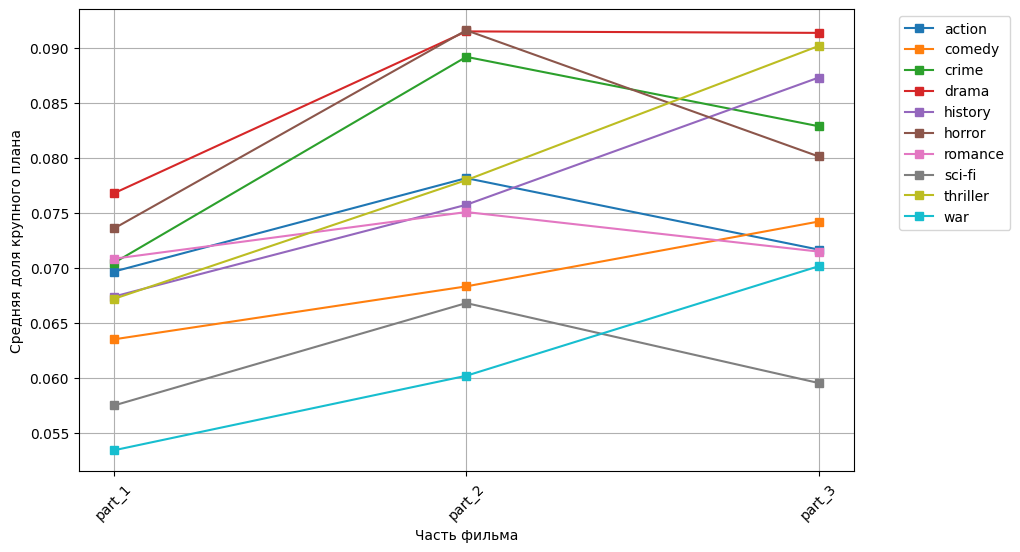

In [ ]:
part_viz(genre_shot_cu_df.sort_index(), 'Средняя доля крупного плана')

#### Количество объектов

In [ ]:
epsilon_squared_fast(metadata_df, 'genre', 'nobjects')

np.float64(0.061494840935992987)

In [ ]:
metadata_df.groupby('genre')['nobjects'].mean().sort_values()

,nobjects
genre,
action,124.04
horror,135.87
sci-fi,143.70
crime,144.04
thriller,144.17
drama,154.98
romance,161.01
history,166.26
war,181.80


In [ ]:
genre_shot_nobj_df = genre_act_correlation('nobjects', num=3, mean='mean').sort_values('part_1')
genre_shot_nobj_df

,part_1,part_2,part_3
genre,,,
action,129.72,122.73,119.63
sci-fi,148.31,145.76,137.02
crime,149.00,139.82,143.31
thriller,155.38,133.02,144.08
horror,161.19,131.76,114.46
romance,163.28,165.21,154.65
drama,167.20,152.64,144.99
history,171.65,171.96,155.22
war,184.28,181.69,179.33


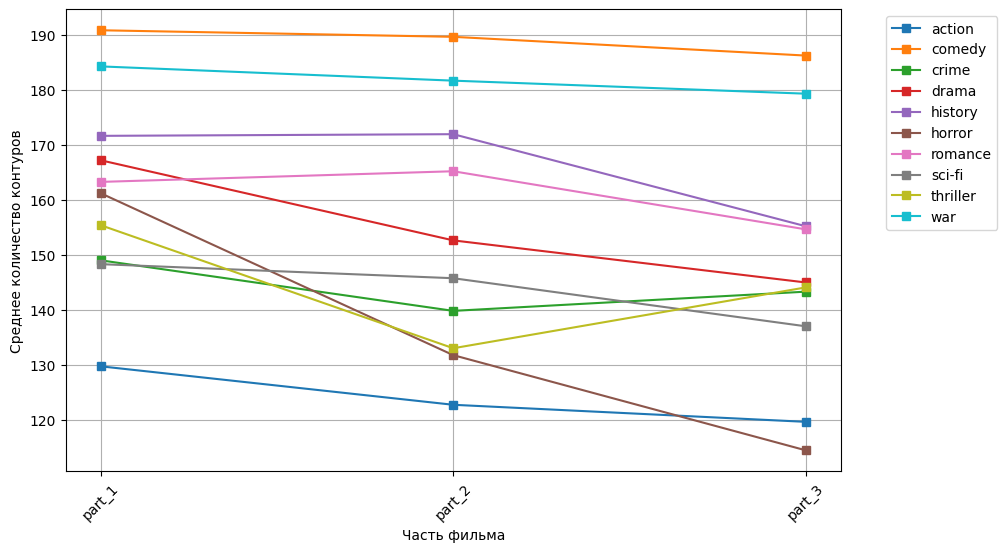

In [ ]:
part_viz(genre_shot_nobj_df.sort_index(), 'Среднее количество контуров')

#### Яркость

In [ ]:
epsilon_squared_fast(metadata_df, 'genre', 'brightness')

np.float64(0.05021949791779568)

In [ ]:
metadata_df.groupby('genre')['brightness'].mean().sort_values()

,brightness
genre,
horror,45.34
action,50.03
thriller,50.31
crime,50.54
sci-fi,52.10
drama,52.19
romance,53.62
history,57.31
comedy,58.49


In [ ]:
genre_shot_bright_df = genre_act_correlation('brightness', num=3, mean='mean').sort_values('part_1')
genre_shot_bright_df

,part_1,part_2,part_3
genre,,,
action,49.11,51.03,49.95
crime,49.27,50.33,52.03
horror,50.41,45.55,40.04
sci-fi,52.40,53.88,50.00
thriller,52.46,47.95,50.50
drama,54.55,51.96,50.05
romance,55.32,52.43,53.12
history,56.80,59.98,55.16
war,57.87,59.28,60.69


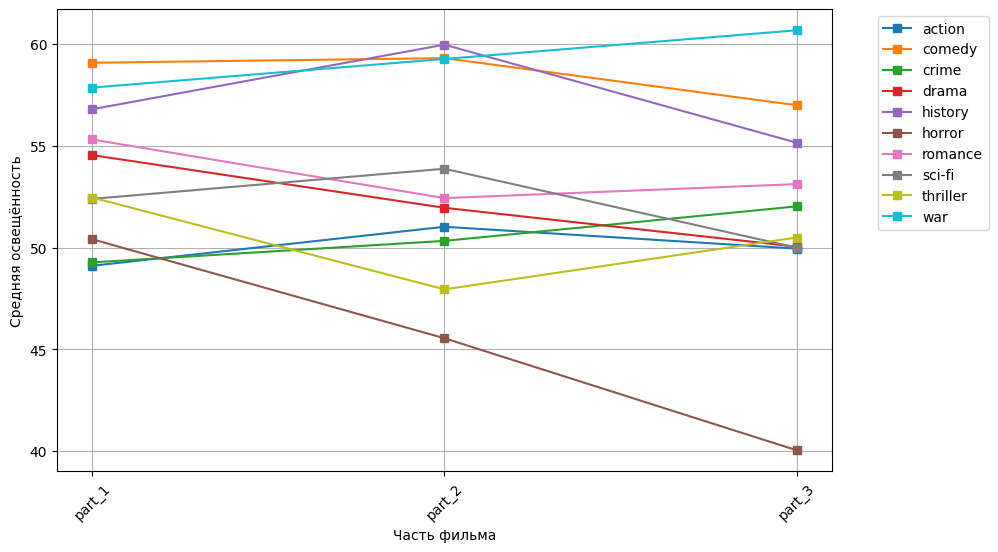

In [ ]:
part_viz(genre_shot_bright_df.sort_index(), 'Средняя освещённость')

### Крупный план

#### длительность

Text(0, 0.5, 'Доля среднего и крупного плана')

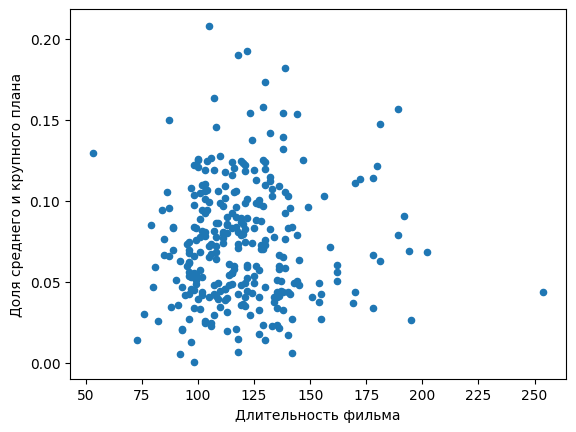

In [ ]:
metadata_df.plot(kind='scatter', x='runtime', y='cu')
plt.xlabel('Длительность фильма')
plt.ylabel('Доля среднего и крупного плана')

Text(0, 0.5, 'Доля крупного плана')

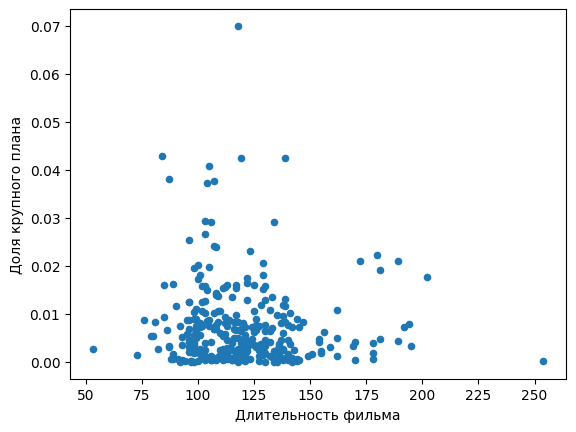

In [ ]:
metadata_df.plot(kind='scatter', x='runtime', y='cu_close')
plt.xlabel('Длительность фильма')
plt.ylabel('Доля крупного плана')

#### дата выхода - не будем смотреть, потому что в разных месяцах разные жанры

#### соотношение сторон

<Axes: xlabel='screen_ratio', ylabel='cu'>

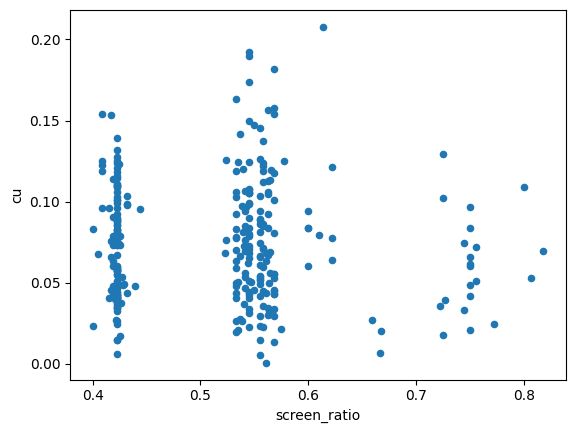

In [ ]:
metadata_df.plot(kind='scatter', x='screen_ratio', y='cu')

Text(0, 0.5, 'Доля крупного плана')

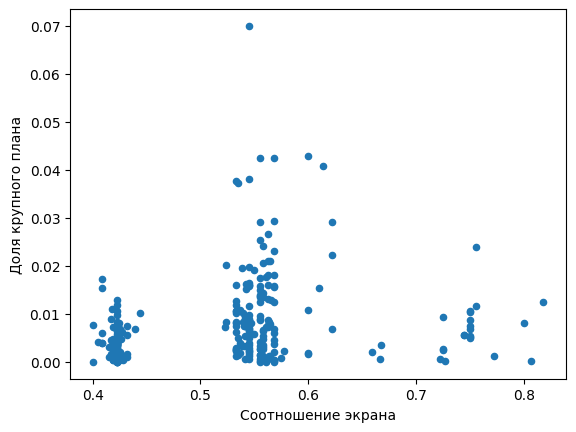

In [ ]:
metadata_df.plot(kind='scatter', x='screen_ratio', y='cu_close')
plt.xlabel('Соотношение экрана')
plt.ylabel('Доля крупного плана')

In [ ]:
metadata_df.groupby('screen_ratio_wide')[['cu_close', 'cu_medium', 'cu']].mean()

,cu_close,cu_medium,cu
screen_ratio_wide,,,
0,0.01,0.07,0.08
1,0.00,0.07,0.07


#### длина плана

In [ ]:
если у нас крупный план длинный, то будет перекос: крупный план будет посчитан больше раз, и средняя длина плана перекосится

мы хотим вот как: собрать все кадры с крупными планами, и оставить из них только уникальные номера планов


In [ ]:
for i in ['closeup', 'medium closeup', 'human', 'none']:
  print(i)
  print(frames_df[frames_df['closeup'] == i].drop_duplicates(subset=['shot_index', 'title'])['time_length'].mean())
  print(frames_df[frames_df['closeup'] == i].drop_duplicates(subset=['shot_index', 'title'])['time_length'].median())
  print(frames_df[frames_df['closeup'] == i].drop_duplicates(subset=['shot_index', 'title'])['time_length'].min())
  print(frames_df[frames_df['closeup'] == i].drop_duplicates(subset=['shot_index', 'title'])['time_length'].max())

closeup
6.63739161849711
4.083333333333333
0.125
185.875
medium closeup
5.911215983804229
3.6666666666666665
0.0416666666666666
359.125
human
7.034348933127007
4.125
0.0416666666666666
493.6666666666667
none
5.841901894073584
3.5416666666666665
0.0416666666666666
493.6666666666667


крупный план: человек говорит
средний план: действие
дальний план: действие, но больше возможностей для длинного плана?
нет людей: короткий панорамный план

#### количество объектов

Text(0, 0.5, 'Доля лица на экране')

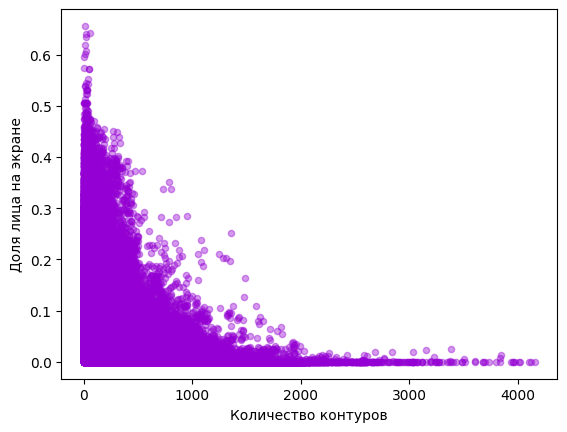

In [ ]:
frames_df.plot(kind='scatter', x='nobjects', y='fsquare', alpha=0.4, color='darkviolet')
plt.xlabel('Количество контуров')
plt.ylabel('Доля лица на экране')

In [ ]:
frames_df['nobjects'].corr(frames_df['fsquare'], method='spearman')

np.float64(-0.07520696995985113)

In [ ]:
frames_df.groupby('closeup')['nobjects'].agg(['mean', 'median', 'max'])

,mean,median,max
closeup,,,
closeup,53.73,37.00,1354.00
human,165.92,121.00,3851.00
medium closeup,71.18,50.00,1585.00
none,157.61,100.00,4158.00


#### Яркость

Text(0, 0.5, 'Доля лица на экране')

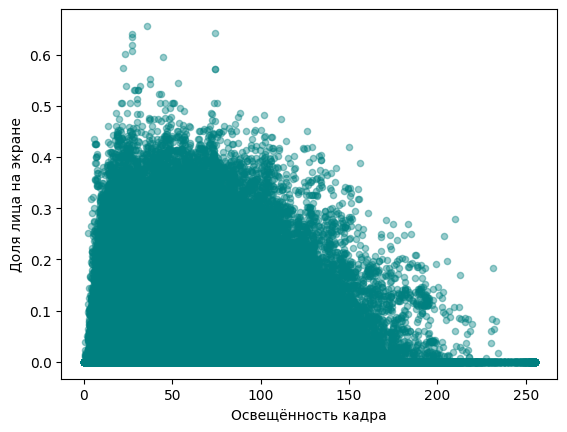

In [ ]:
frames_df.plot(kind='scatter', x='brightness', y='fsquare', alpha=0.4, color='teal')
plt.xlabel('Освещённость кадра')
plt.ylabel('Доля лица на экране')

In [ ]:
frames_df['brightness'].corr(frames_df['fsquare'], method='spearman')

np.float64(0.006126556424704938)

In [ ]:
frames_df.groupby('closeup')['brightness'].agg(['mean', 'median', 'max'])

,mean,median,max
closeup,,,
closeup,50.52,46.71,209.76
human,52.99,49.42,234.13
medium closeup,50.49,46.31,231.25
none,53.11,47.61,255.00


### Длина плана


#### длительность фильма

Text(0, 0.5, 'Длительность фильма')

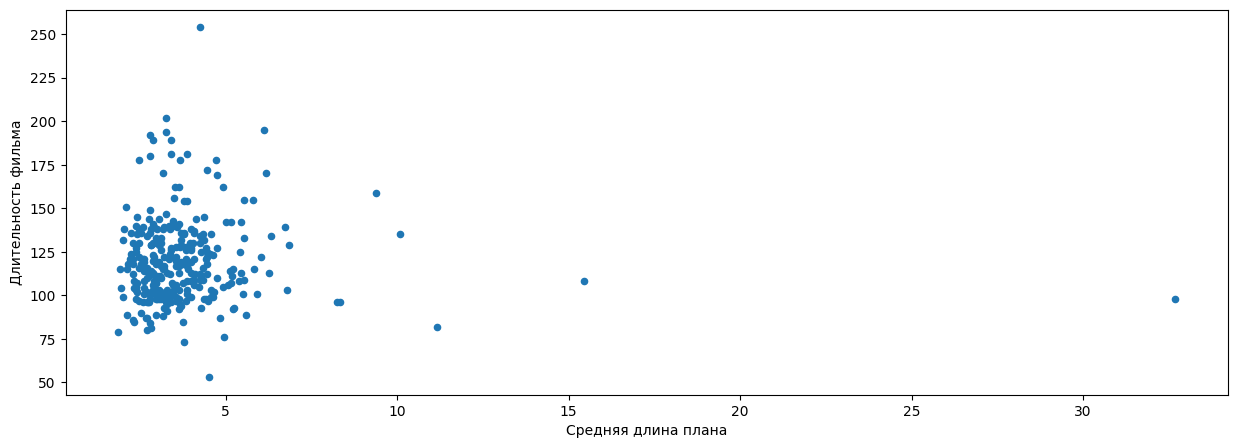

In [ ]:
metadata_df.plot(kind='scatter', x='median_scene', y='runtime', figsize=(15, 5))
plt.xlabel('Средняя длина плана')
plt.ylabel('Длительность фильма')

#### соотношение сторон

Text(0, 0.5, 'Средняя длина плана')

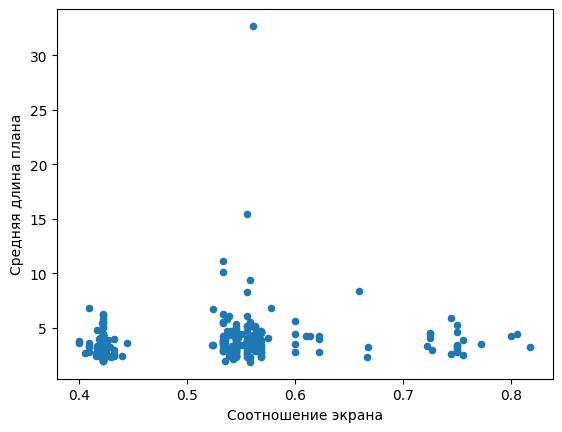

In [ ]:
metadata_df.plot(kind='scatter', x='screen_ratio', y='median_scene')
plt.xlabel('Соотношение экрана')
plt.ylabel('Средняя длина плана')

In [ ]:
metadata_df.groupby('screen_ratio_wide')[['mean_scene']].agg(['mean', 'min', 'max'])

mean_scene           
                        mean  min   max
screen_ratio_wide                      
0                       6.70 2.74 45.60
1                       5.13 2.47 11.34

#### количество лиц

Text(0, 0.5, 'Средняя длина плана')

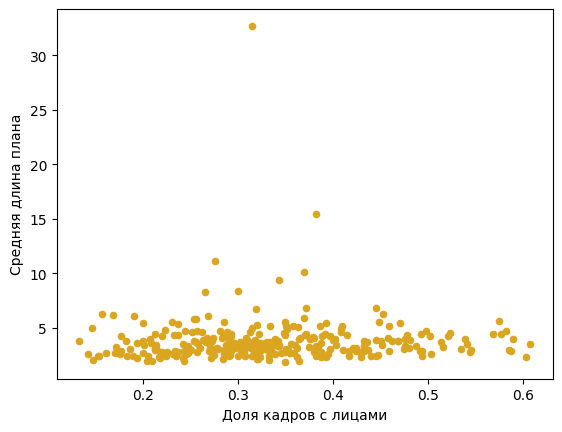

In [ ]:
metadata_df.plot(kind='scatter', x='faces_bool', y='median_scene', color='goldenrod')
plt.xlabel('Доля кадров с лицами')
plt.ylabel('Средняя длина плана')

In [ ]:
frames_df['faces'].value_counts().head(6)

,count
faces,
0,1354066
1,560495
2,91415
3,18520
4,5341
5,2124


In [ ]:
for i in [0, 1, 2, 3]:
  print(f'{i} лиц')
  print(frames_df[frames_df['faces'] == i].drop_duplicates(subset=['shot_index', 'title'])['time_length'].mean())
  print(frames_df[frames_df['faces'] == i].drop_duplicates(subset=['shot_index', 'title'])['time_length'].median())

0 лиц
5.841901894073584
3.5416666666666665
1 лиц
6.7298289724903855
4.0
2 лиц
8.972640527544781
4.916666666666667
3 лиц
9.72277587952417
5.041666666666667


#### количество объектов

In [ ]:
mean_values = frames_df.groupby(['title', 'shot_index'])['nobjects'].mean().reset_index()
shot_df = shot_df.merge(mean_values, on=['title', 'shot_index'], how='left')

Text(0, 0.5, 'Количество контуров')

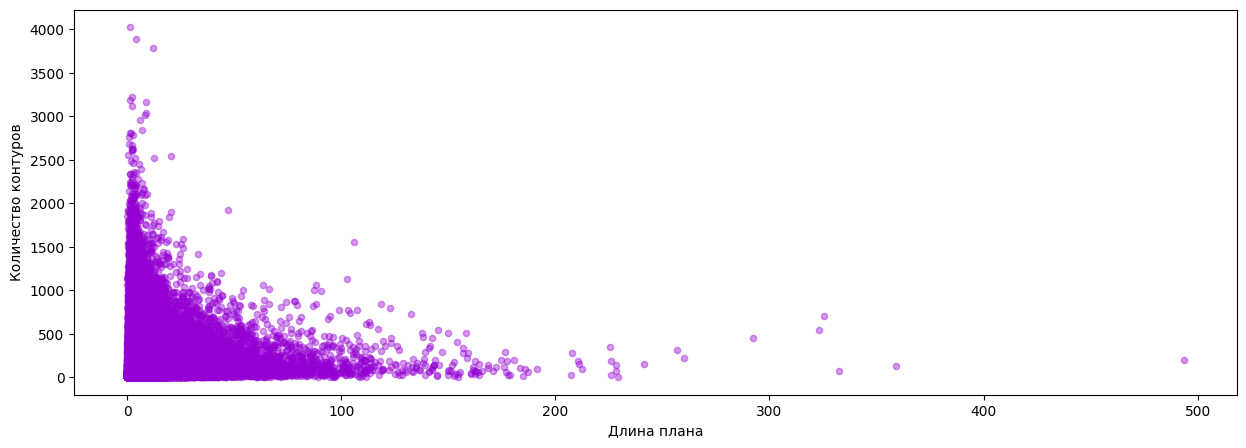

In [ ]:
shot_df.plot(kind='scatter', x='time_length', y='nobjects', figsize=(15, 5), alpha=0.4, color='darkviolet')
plt.xlabel('Длина плана')
plt.ylabel('Количество контуров')

In [ ]:
for i in [0, 50, 100, 200, 500, 1000, 2000]:
  print(f'более {i} объектов')
  print(round(frames_df[frames_df['nobjects'] >= i].drop_duplicates(subset=['shot_index', 'title'])['time_length'].mean(), 3))
  print(round(frames_df[frames_df['nobjects'] >= i].drop_duplicates(subset=['shot_index', 'title'])['time_length'].median(), 3))
  print(round(frames_df[frames_df['nobjects'] >= i].drop_duplicates(subset=['shot_index', 'title'])['time_length'].max(), 3))

более 0 объектов
5.282
3.25
493.667
более 50 объектов
5.704
3.458
493.667
более 100 объектов
6.175
3.667
493.667
более 200 объектов
6.926
4.0
493.667
более 500 объектов
8.124
4.458
325.625
более 1000 объектов
8.981
4.792
141.125
более 2000 объектов
8.169
5.167
58.792


#### яркость

In [ ]:
mean_values = frames_df.groupby(['title', 'shot_index'])['brightness'].mean().reset_index()
shot_df = shot_df.merge(mean_values, on=['title', 'shot_index'], how='left')

Text(0, 0.5, 'Освещённость кадра')

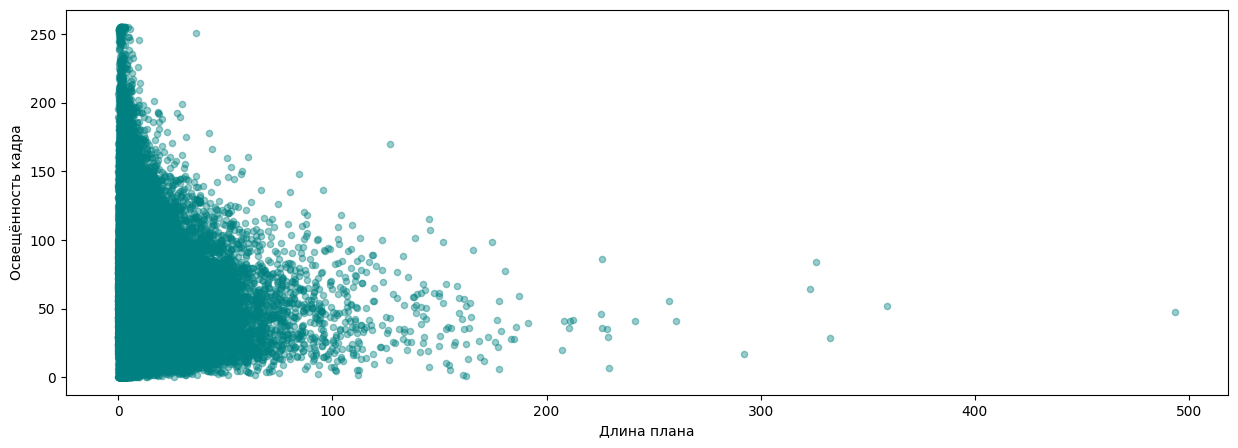

In [ ]:
shot_df.plot(kind='scatter', x='time_length', y='brightness', figsize=(15, 5), alpha=0.4, color='teal')
plt.xlabel('Длина плана')
plt.ylabel('Освещённость кадра')

In [ ]:
for i in [0, 50, 100, 150, 200]:
  print(f'яркость {i}')
  print(round(frames_df[frames_df['brightness'] >= i].drop_duplicates(subset=['shot_index', 'title'])['time_length'].mean(), 3))
  print(round(frames_df[frames_df['brightness'] >= i].drop_duplicates(subset=['shot_index', 'title'])['time_length'].median(), 3))
  print(round(frames_df[frames_df['brightness'] >= i].drop_duplicates(subset=['shot_index', 'title'])['time_length'].max(), 3))

яркость 0
5.282
3.25
493.667
яркость 50
5.582
3.333
493.667
яркость 100
6.147
3.458
225.875
яркость 150
6.347
3.5
187.167
яркость 200
6.963
3.792
143.333


### съёмочная группа

#### крупный план

In [39]:
def names_correlation_2(kind, names_list, features_list):
    data = []
    for name in names_list:
        films = metadata_df[metadata_df[kind].str.contains(name)]
        row = {'name': name}
        for f in features_list:
            row[f] = round(films[f].mean(), 2)
        data.append(row)
    return pd.DataFrame(data).sort_values('name')

In [40]:
names_correlation_2('directors', directors, ['cu', 'mean_scene', 'nobjects', 'brightness'])

,name,cu,mean_scene,nobjects,brightness
21,Abel Ferrara,0.06,13.15,126.66,41.07
12,Ang Lee,0.04,7.67,174.35,54.12
0,Clint Eastwood,0.03,6.15,154.23,58.14
19,David Fincher,0.03,4.46,103.27,42.60
22,Ethan Coen,0.06,6.54,174.45,48.92
13,James Cameron,0.05,4.15,152.04,67.60
10,Joel Coen,0.06,6.54,174.45,48.92
15,Joel Schumacher,0.09,4.84,107.02,50.54
3,Martin Scorsese,0.06,6.01,124.56,51.50
2,Neil Jordan,0.07,8.05,77.33,39.31


In [41]:
names_correlation_2('writers', writers, ['cu', 'mean_scene', 'nobjects', 'brightness'])

,name,cu,mean_scene,nobjects,brightness
14,Andrew Kevin Walker,0.06,4.36,125.22,41.60
11,Bruce Joel Rubin,0.09,4.98,130.89,49.98
13,David Koepp,0.06,6.19,147.67,48.35
16,David Mamet,0.09,6.07,174.61,53.39
17,David Twohy,0.07,4.22,133.20,55.21
18,Dean Devlin,0.05,3.40,128.84,61.95
12,Donald E. Stewart,0.08,5.68,125.77,48.59
8,Ethan Coen,0.06,6.54,174.45,48.92
5,James Cameron,0.05,4.15,152.04,67.60
3,Joel Coen,0.06,6.54,174.45,48.92


In [42]:
names_correlation_2('actors', actors, ['cu', 'mean_scene', 'nobjects', 'brightness'])

,name,cu,mean_scene,nobjects,brightness
13,Al Pacino,0.09,5.66,140.83,44.64
25,Anthony Hopkins,0.08,6.69,134.17,45.34
27,Brad Pitt,0.09,5.50,122.84,48.58
14,Bruce Willis,0.07,4.77,123.01,48.61
10,Christopher Walken,0.07,9.38,190.02,61.34
20,Clint Eastwood,0.04,5.90,141.27,56.10
22,Danny Glover,0.07,5.12,155.55,58.40
12,Gary Oldman,0.07,6.54,120.87,43.09
30,Gene Hackman,0.07,4.81,122.80,47.53
6,Harvey Keitel,0.06,8.80,113.04,44.47


In [31]:
names_correlation('directors', directors, 'cu')

(0.03, 'Clint Eastwood')
(0.03, 'David Fincher')
(0.03, 'Steven Spielberg')
(0.04, 'Ang Lee')
(0.05, 'James Cameron')
(0.05, 'Quentin Tarantino')
(0.05, 'Roland Emmerich')
(0.05, 'Terry Gilliam')
(0.06, 'Abel Ferrara')
(0.06, 'Ethan Coen')
(0.06, 'Joel Coen')
(0.06, 'Martin Scorsese')
(0.06, 'Tim Burton')
(0.06, 'Woody Allen')
(0.07, 'Neil Jordan')
(0.07, 'Oliver Stone')
(0.07, 'Tony Scott')
(0.08, 'Sam Raimi')
(0.09, 'Joel Schumacher')
(0.09, 'Paul Verhoeven')
(0.1, 'Robert Rodriguez')
(0.1, 'Wes Craven')
(0.16, 'Rob Reiner')


In [32]:
names_correlation('directors', directors, 'cu_close')

(0.0, 'Ang Lee')
(0.0, 'Clint Eastwood')
(0.0, 'David Fincher')
(0.0, 'Ethan Coen')
(0.0, 'Joel Coen')
(0.0, 'Joel Schumacher')
(0.0, 'Martin Scorsese')
(0.0, 'Quentin Tarantino')
(0.0, 'Roland Emmerich')
(0.0, 'Steven Spielberg')
(0.0, 'Tony Scott')
(0.01, 'James Cameron')
(0.01, 'Neil Jordan')
(0.01, 'Oliver Stone')
(0.01, 'Paul Verhoeven')
(0.01, 'Sam Raimi')
(0.01, 'Terry Gilliam')
(0.01, 'Tim Burton')
(0.01, 'Wes Craven')
(0.01, 'Woody Allen')
(0.02, 'Abel Ferrara')
(0.02, 'Rob Reiner')
(0.02, 'Robert Rodriguez')


In [33]:
names_correlation('writers', writers, 'cu')

(0.05, 'Dean Devlin')
(0.05, 'James Cameron')
(0.05, 'Neil Jordan')
(0.05, 'Roland Emmerich')
(0.06, 'Andrew Kevin Walker')
(0.06, 'David Koepp')
(0.06, 'Ethan Coen')
(0.06, 'Joel Coen')
(0.06, 'Quentin Tarantino')
(0.06, 'Roger Avary')
(0.06, 'Woody Allen')
(0.07, 'David Twohy')
(0.07, 'Richard LaGravenese')
(0.07, 'Shane Black')
(0.07, 'Steven Zaillian')
(0.08, 'Donald E. Stewart')
(0.08, 'Tom Clancy')
(0.09, 'Bruce Joel Rubin')
(0.09, 'David Mamet')
(0.1, 'Kevin Williamson')
(0.11, 'Stephen King')


In [34]:
names_correlation('writers', writers, 'cu_close')

(0.0, 'David Koepp')
(0.0, 'Dean Devlin')
(0.0, 'Ethan Coen')
(0.0, 'Joel Coen')
(0.0, 'Roger Avary')
(0.0, 'Roland Emmerich')
(0.0, 'Shane Black')
(0.01, 'Andrew Kevin Walker')
(0.01, 'Bruce Joel Rubin')
(0.01, 'David Mamet')
(0.01, 'David Twohy')
(0.01, 'Donald E. Stewart')
(0.01, 'James Cameron')
(0.01, 'Kevin Williamson')
(0.01, 'Neil Jordan')
(0.01, 'Quentin Tarantino')
(0.01, 'Richard LaGravenese')
(0.01, 'Steven Zaillian')
(0.01, 'Tom Clancy')
(0.01, 'Woody Allen')
(0.02, 'Stephen King')


In [35]:
names_correlation('actors', actors, 'cu')

(0.04, 'Clint Eastwood')
(0.05, 'John Cusack')
(0.05, 'Kevin Costner')
(0.06, 'Harvey Keitel')
(0.06, 'Johnny Depp')
(0.06, 'Liam Neeson')
(0.06, 'Sandra Bullock')
(0.06, 'Sharon Stone')
(0.06, 'Willem Dafoe')
(0.07, 'Bruce Willis')
(0.07, 'Christopher Walken')
(0.07, 'Danny Glover')
(0.07, 'Gary Oldman')
(0.07, 'Gene Hackman')
(0.07, 'Jeff Bridges')
(0.07, 'Joe Pesci')
(0.07, 'Samuel L. Jackson')
(0.07, 'Tom Hanks')
(0.08, 'Anthony Hopkins')
(0.08, 'John Turturro')
(0.08, 'Kevin Bacon')
(0.08, 'Michael Douglas')
(0.08, 'Nicolas Cage')
(0.08, 'Robert De Niro')
(0.08, 'Robert Duvall')
(0.08, 'Sam Neill')
(0.08, 'Sean Penn')
(0.08, 'Tim Robbins')
(0.09, 'Al Pacino')
(0.09, 'Brad Pitt')
(0.09, 'Keanu Reeves')
(0.09, 'Kevin Spacey')
(0.09, 'Leon')
(0.09, 'Matt Damon')
(0.1, 'Ralph Fiennes')
(0.11, 'Tom Cruise')
(0.11, 'Winona Ryder')
(0.12, 'Jack Nicholson')


In [36]:
names_correlation('actors', actors, 'cu_close')

(0.0, 'Al Pacino')
(0.0, 'Clint Eastwood')
(0.0, 'Gene Hackman')
(0.0, 'John Cusack')
(0.0, 'Kevin Costner')
(0.0, 'Kevin Spacey')
(0.0, 'Michael Douglas')
(0.0, 'Robert Duvall')
(0.0, 'Samuel L. Jackson')
(0.0, 'Sandra Bullock')
(0.0, 'Sean Penn')
(0.0, 'Willem Dafoe')
(0.01, 'Anthony Hopkins')
(0.01, 'Brad Pitt')
(0.01, 'Bruce Willis')
(0.01, 'Christopher Walken')
(0.01, 'Danny Glover')
(0.01, 'Gary Oldman')
(0.01, 'Harvey Keitel')
(0.01, 'Jeff Bridges')
(0.01, 'Joe Pesci')
(0.01, 'John Turturro')
(0.01, 'Johnny Depp')
(0.01, 'Keanu Reeves')
(0.01, 'Kevin Bacon')
(0.01, 'Leon')
(0.01, 'Liam Neeson')
(0.01, 'Matt Damon')
(0.01, 'Nicolas Cage')
(0.01, 'Robert De Niro')
(0.01, 'Sam Neill')
(0.01, 'Sharon Stone')
(0.01, 'Tim Robbins')
(0.01, 'Tom Cruise')
(0.01, 'Tom Hanks')
(0.01, 'Winona Ryder')
(0.02, 'Jack Nicholson')
(0.02, 'Ralph Fiennes')


#### длина плана

In [ ]:
names_correlation('directors', directors, 'mean_scene')

(3.33, 'Tony Scott')
(3.4, 'Roland Emmerich')
(3.73, 'Robert Rodriguez')
(4.15, 'James Cameron')
(4.41, 'Wes Craven')
(4.46, 'David Fincher')
(4.46, 'Oliver Stone')
(4.76, 'Paul Verhoeven')
(4.84, 'Joel Schumacher')
(5.29, 'Sam Raimi')
(5.29, 'Tim Burton')
(5.44, 'Rob Reiner')
(6.01, 'Martin Scorsese')
(6.15, 'Clint Eastwood')
(6.54, 'Ethan Coen')
(6.54, 'Joel Coen')
(6.76, 'Terry Gilliam')
(7.67, 'Ang Lee')
(7.98, 'Quentin Tarantino')
(8.05, 'Neil Jordan')
(8.18, 'Steven Spielberg')
(13.15, 'Abel Ferrara')
(30.92, 'Woody Allen')


In [ ]:
names_correlation('writers', writers, 'mean_scene')

(3.22, 'Shane Black')
(3.4, 'Dean Devlin')
(3.4, 'Roland Emmerich')
(4.07, 'Kevin Williamson')
(4.15, 'James Cameron')
(4.22, 'David Twohy')
(4.36, 'Andrew Kevin Walker')
(4.98, 'Bruce Joel Rubin')
(5.68, 'Donald E. Stewart')
(5.68, 'Tom Clancy')
(5.69, 'Stephen King')
(5.83, 'Quentin Tarantino')
(6.07, 'David Mamet')
(6.19, 'David Koepp')
(6.28, 'Steven Zaillian')
(6.54, 'Ethan Coen')
(6.54, 'Joel Coen')
(6.81, 'Roger Avary')
(8.29, 'Richard LaGravenese')
(8.37, 'Neil Jordan')
(30.92, 'Woody Allen')


In [ ]:
names_correlation('actors', actors, 'mean_scene')

(3.97, 'Keanu Reeves')
(4.54, 'Nicolas Cage')
(4.55, 'Kevin Spacey')
(4.68, 'Kevin Costner')
(4.77, 'Bruce Willis')
(4.81, 'Gene Hackman')
(4.82, 'Sharon Stone')
(4.89, 'Leon')
(4.98, 'Joe Pesci')
(5.07, 'Robert De Niro')
(5.12, 'Danny Glover')
(5.12, 'Sandra Bullock')
(5.31, 'Samuel L. Jackson')
(5.39, 'Willem Dafoe')
(5.49, 'Sam Neill')
(5.5, 'Brad Pitt')
(5.66, 'Al Pacino')
(5.68, 'Jack Nicholson')
(5.71, 'Michael Douglas')
(5.9, 'Clint Eastwood')
(6.01, 'John Turturro')
(6.08, 'Johnny Depp')
(6.09, 'Kevin Bacon')
(6.26, 'Robert Duvall')
(6.31, 'Tim Robbins')
(6.36, 'Matt Damon')
(6.54, 'Gary Oldman')
(6.67, 'Tom Hanks')
(6.69, 'Anthony Hopkins')
(6.74, 'Ralph Fiennes')
(6.76, 'Liam Neeson')
(6.97, 'Jeff Bridges')
(7.09, 'Sean Penn')
(7.45, 'Tom Cruise')
(7.54, 'Winona Ryder')
(8.8, 'Harvey Keitel')
(9.38, 'Christopher Walken')
(14.65, 'John Cusack')


#### количество объектов

In [ ]:
names_correlation('directors', directors, 'nobjects')

(77.33, 'Neil Jordan')
(103.27, 'David Fincher')
(107.02, 'Joel Schumacher')
(115.37, 'Oliver Stone')
(118.97, 'Tony Scott')
(121.71, 'Robert Rodriguez')
(124.56, 'Martin Scorsese')
(126.66, 'Abel Ferrara')
(128.84, 'Roland Emmerich')
(152.04, 'James Cameron')
(154.23, 'Clint Eastwood')
(156.65, 'Sam Raimi')
(157.9, 'Wes Craven')
(161.18, 'Rob Reiner')
(172.2, 'Paul Verhoeven')
(174.35, 'Ang Lee')
(174.45, 'Ethan Coen')
(174.45, 'Joel Coen')
(177.42, 'Tim Burton')
(178.29, 'Terry Gilliam')
(188.07, 'Quentin Tarantino')
(224.46, 'Woody Allen')
(238.13, 'Steven Spielberg')


In [ ]:
names_correlation('writers', writers, 'nobjects')

(83.57, 'Neil Jordan')
(125.22, 'Andrew Kevin Walker')
(125.77, 'Donald E. Stewart')
(125.77, 'Tom Clancy')
(128.84, 'Dean Devlin')
(130.89, 'Bruce Joel Rubin')
(133.2, 'David Twohy')
(135.3, 'Roland Emmerich')
(140.59, 'Shane Black')
(147.67, 'David Koepp')
(152.04, 'James Cameron')
(153.31, 'Quentin Tarantino')
(165.04, 'Kevin Williamson')
(166.34, 'Roger Avary')
(174.45, 'Ethan Coen')
(174.45, 'Joel Coen')
(174.61, 'David Mamet')
(178.23, 'Stephen King')
(178.65, 'Steven Zaillian')
(182.2, 'Richard LaGravenese')
(224.46, 'Woody Allen')


In [ ]:
names_correlation('actors', actors, 'nobjects')

(99.93, 'Kevin Spacey')
(105.48, 'Kevin Bacon')
(108.99, 'Robert De Niro')
(109.33, 'Nicolas Cage')
(110.22, 'Michael Douglas')
(113.04, 'Harvey Keitel')
(118.81, 'Sharon Stone')
(120.87, 'Gary Oldman')
(120.92, 'Sandra Bullock')
(120.95, 'Winona Ryder')
(122.21, 'Sam Neill')
(122.8, 'Gene Hackman')
(122.84, 'Brad Pitt')
(123.01, 'Bruce Willis')
(124.4, 'Keanu Reeves')
(128.01, 'Willem Dafoe')
(133.4, 'Tom Cruise')
(134.09, 'Ralph Fiennes')
(134.17, 'Anthony Hopkins')
(137.7, 'Jack Nicholson')
(138.66, 'Joe Pesci')
(140.83, 'Al Pacino')
(141.27, 'Clint Eastwood')
(143.03, 'Liam Neeson')
(143.71, 'Tim Robbins')
(147.8, 'Leon')
(148.2, 'Sean Penn')
(148.58, 'Samuel L. Jackson')
(155.55, 'Danny Glover')
(158.65, 'Jeff Bridges')
(161.22, 'Robert Duvall')
(165.78, 'Johnny Depp')
(170.89, 'Kevin Costner')
(172.99, 'John Turturro')
(182.51, 'John Cusack')
(190.02, 'Christopher Walken')
(232.44, 'Matt Damon')
(249.38, 'Tom Hanks')


#### яркость

In [ ]:
names_correlation('directors', directors, 'brightness')

(39.31, 'Neil Jordan')
(41.07, 'Abel Ferrara')
(42.6, 'David Fincher')
(44.64, 'Wes Craven')
(45.18, 'Woody Allen')
(46.59, 'Robert Rodriguez')
(47.45, 'Tim Burton')
(48.22, 'Tony Scott')
(48.92, 'Ethan Coen')
(48.92, 'Joel Coen')
(50.54, 'Joel Schumacher')
(51.5, 'Martin Scorsese')
(53.4, 'Quentin Tarantino')
(54.12, 'Ang Lee')
(54.26, 'Sam Raimi')
(54.27, 'Terry Gilliam')
(57.33, 'Paul Verhoeven')
(57.59, 'Oliver Stone')
(58.14, 'Clint Eastwood')
(58.36, 'Rob Reiner')
(61.88, 'Steven Spielberg')
(61.95, 'Roland Emmerich')
(67.6, 'James Cameron')


In [ ]:
names_correlation('writers', writers, 'brightness')

(41.6, 'Andrew Kevin Walker')
(45.01, 'Neil Jordan')
(45.18, 'Woody Allen')
(48.35, 'David Koepp')
(48.59, 'Donald E. Stewart')
(48.59, 'Tom Clancy')
(48.92, 'Ethan Coen')
(48.92, 'Joel Coen')
(49.98, 'Bruce Joel Rubin')
(51.06, 'Kevin Williamson')
(52.1, 'Roger Avary')
(52.74, 'Richard LaGravenese')
(53.39, 'David Mamet')
(54.91, 'Quentin Tarantino')
(55.21, 'David Twohy')
(55.83, 'Stephen King')
(56.21, 'Shane Black')
(59.22, 'Steven Zaillian')
(61.95, 'Dean Devlin')
(63.29, 'Roland Emmerich')
(67.6, 'James Cameron')


In [ ]:
names_correlation('actors', actors, 'brightness')

(39.39, 'Winona Ryder')
(39.97, 'Kevin Bacon')
(42.33, 'Sam Neill')
(43.09, 'Gary Oldman')
(43.16, 'John Cusack')
(44.47, 'Harvey Keitel')
(44.64, 'Al Pacino')
(45.34, 'Anthony Hopkins')
(46.08, 'Kevin Spacey')
(46.32, 'Robert De Niro')
(46.43, 'Michael Douglas')
(47.53, 'Gene Hackman')
(48.58, 'Brad Pitt')
(48.61, 'Bruce Willis')
(48.73, 'Tom Cruise')
(48.97, 'Liam Neeson')
(50.22, 'Samuel L. Jackson')
(50.24, 'Johnny Depp')
(50.81, 'Keanu Reeves')
(51.76, 'Jack Nicholson')
(52.29, 'Sharon Stone')
(52.83, 'Jeff Bridges')
(53.05, 'Sean Penn')
(53.07, 'John Turturro')
(53.34, 'Joe Pesci')
(54.03, 'Tim Robbins')
(54.6, 'Leon')
(55.11, 'Nicolas Cage')
(55.24, 'Ralph Fiennes')
(55.42, 'Sandra Bullock')
(56.1, 'Clint Eastwood')
(57.42, 'Willem Dafoe')
(58.4, 'Danny Glover')
(61.02, 'Robert Duvall')
(61.34, 'Christopher Walken')
(62.61, 'Matt Damon')
(63.01, 'Tom Hanks')
(69.36, 'Kevin Costner')


## semiclose viewing

In [ ]:
frames_df['minute'] = frames_df['nframe'].apply(lambda x: int(x / 24 // 60))

#frames_df['minute1'] = frames_df['frame_time'].apply(lambda x: int(x.split(':')[0])*60 + int(x.split(':')[1]))
#(frames_df['minute'] == frames_df['minute1']).unique()

In [ ]:
frames_df.sample(5)

,nframe,faces,fsquare,neyes,nobjects,brightness,shot_index,title,start,end,...,time_length,timecode,part,part_of_6,part_of_9,faces_bool,closeup,frame_time,cu,minute
1072011,157776,0,0.00,0,46.00,39.41,1558,GoldenEye,157698.00,157856.00,...,6.58,01:49:30,3.00,6.00,8.00,0,none,01:49:34,0,109
2001127,107448,1,0.01,0,368.00,44.92,914,The_Green_Mile,107414.00,107497.00,...,3.46,01:14:35,2.00,3.00,4.00,1,human,01:14:37,0,74
2088907,34320,0,0.00,1,23.00,16.07,289,The_Thirteenth_Floor,34301.00,34527.00,...,9.42,00:23:49,1.00,2.00,3.00,0,none,00:23:50,0,23
244957,101256,0,0.00,0,267.00,70.23,570,The_Fisher_King,101137.00,101319.00,...,7.58,01:10:14,2.00,4.00,5.00,0,none,01:10:19,0,70
1439121,71880,0,0.00,1,85.00,53.64,328,Michael_Collins,71101.00,72426.00,...,55.21,00:49:22,2.00,3.00,4.00,0,none,00:49:55,0,49


In [ ]:
shot_df['start_minute'] = shot_df['start'].apply(lambda x: int(x / 24 // 60))
shot_df['end_minute'] = shot_df['end'].apply(lambda x: int(x / 24 // 60))

In [ ]:
shot_df.sample(5)

,title,shot_index,start,end,length,time_length,timecode,part,part_of_6,part_of_9,nobjects,brightness,start_minute,end_minute
124362,Gettysburg,1888,335617,335713,96,4.00,03:53:04,3,6,8,134.75,138.31,233,233
145080,Home_Alone,336,40289,40322,33,1.38,00:27:58,1,2,3,212.00,19.11,27,28
145858,Home_Alone,1114,121406,121437,31,1.29,01:24:18,3,6,8,151.00,59.68,84,84
870,A_Bronx_Tale,57,8320,8656,336,14.00,00:05:46,1,1,1,55.93,46.76,5,6
298089,The_Devil's_Advocate,177,16132,16190,58,2.42,00:11:12,1,1,1,102.50,46.40,11,11


In [ ]:
def film_stat(film, feature='faces_bool', f_type='frame', color='blue', ylabel=''):
  if f_type == 'frame':
    result = frames_df[frames_df['title'] == film].groupby('minute')[feature].mean().sort_index()
  elif f_type == 'shot':
    # определить количество минут, и для каждой минуты найти кол-во значений больше или равно левой меньше или равно правой
    df = shot_df[shot_df['title'] == film]
    minutes = df['end_minute'].max()
    result = pd.DataFrame({'minute': range(1, minutes+1)})
    result['shots'] = result['minute'].apply(lambda x: df[(df['start_minute'] <= x)&(df['end_minute'] >= x)].shape[0])
    result = result.set_index('minute')

  ax = result.plot.line(color=color)
  plt.xlabel('Минута фильма')
  plt.ylabel(ylabel)
  if ax.get_legend() is not None:
    ax.get_legend().remove()
    plt.show()

### звездные войны

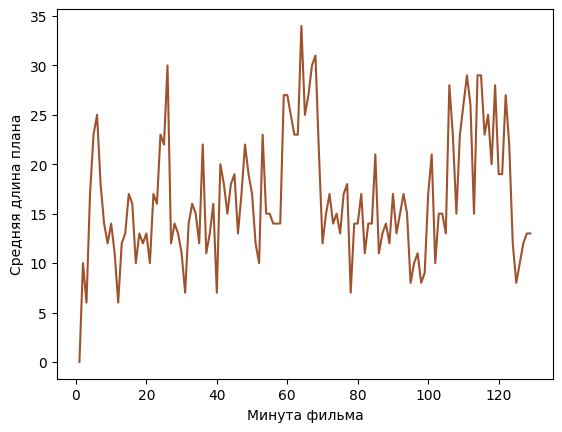

In [ ]:
film_stat('Star_Wars_Episode_I_The_Phantom_Menace', f_type='shot', color='sienna', ylabel='Средняя длина плана')

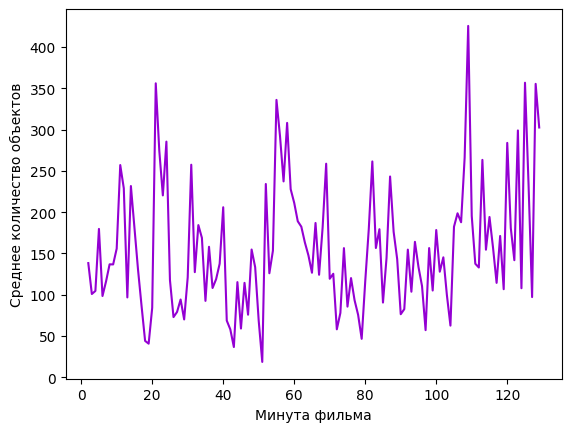

In [ ]:
film_stat('Star_Wars_Episode_I_The_Phantom_Menace', 'nobjects', color='darkviolet', ylabel='Среднее количество объектов')

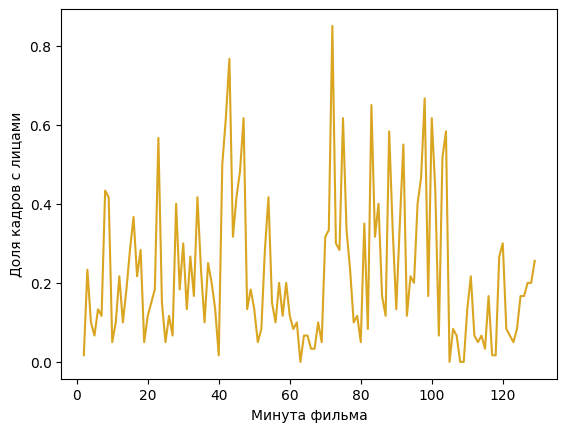

In [ ]:
film_stat('Star_Wars_Episode_I_The_Phantom_Menace', 'faces_bool', color='goldenrod', ylabel='Доля кадров с лицами')

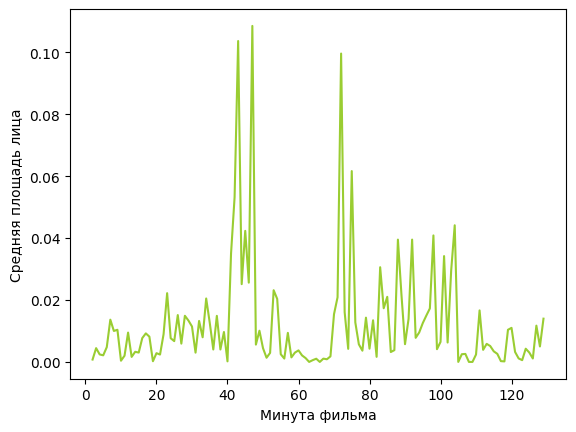

In [ ]:
film_stat('Star_Wars_Episode_I_The_Phantom_Menace', 'fsquare', color='yellowgreen', ylabel='Средняя площадь лица')

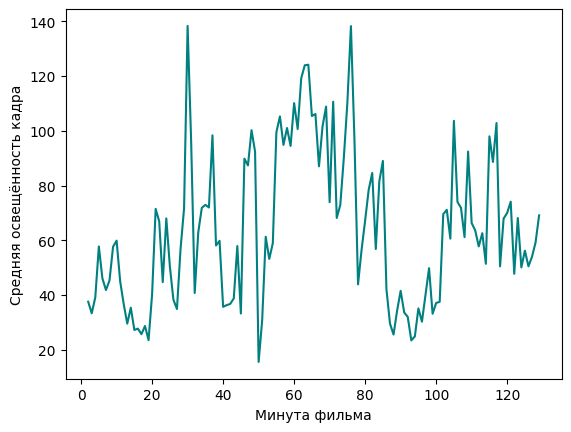

In [ ]:
film_stat('Star_Wars_Episode_I_The_Phantom_Menace', 'brightness', color='teal', ylabel='Средняя освещённость кадра')

### том стоппард

<Axes: xlabel='minute'>

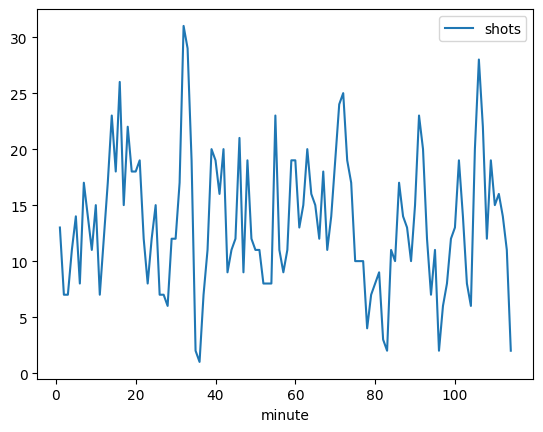

In [ ]:
film_stat('Rosencrantz_&_Guildenstern_Are_Dead', f_type='shot')

<Axes: xlabel='minute'>

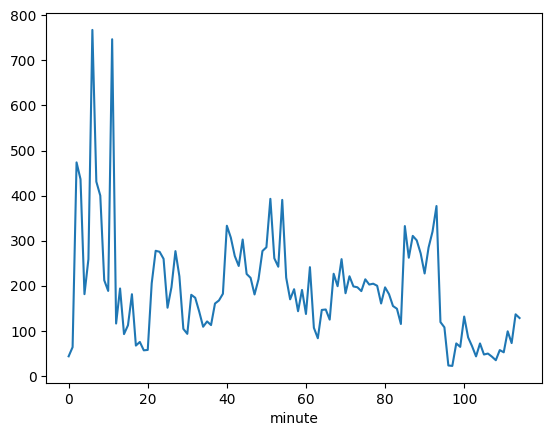

In [ ]:
film_stat('Rosencrantz_&_Guildenstern_Are_Dead', 'nobjects')

<Axes: xlabel='minute'>

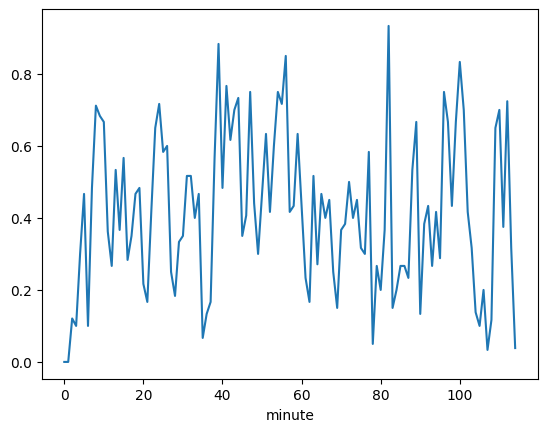

In [ ]:
film_stat('Rosencrantz_&_Guildenstern_Are_Dead', 'faces_bool')

<Axes: xlabel='minute'>

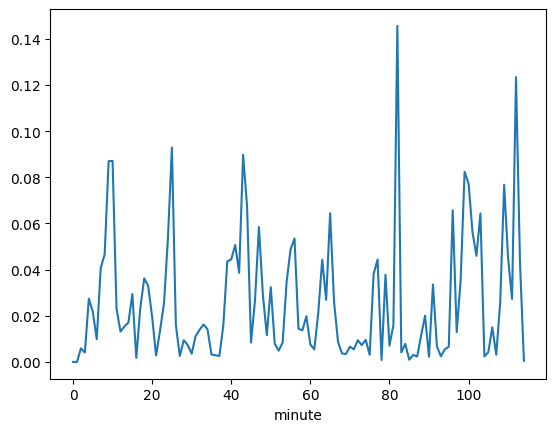

In [ ]:
film_stat('Rosencrantz_&_Guildenstern_Are_Dead', 'fsquare')

<Axes: xlabel='minute'>

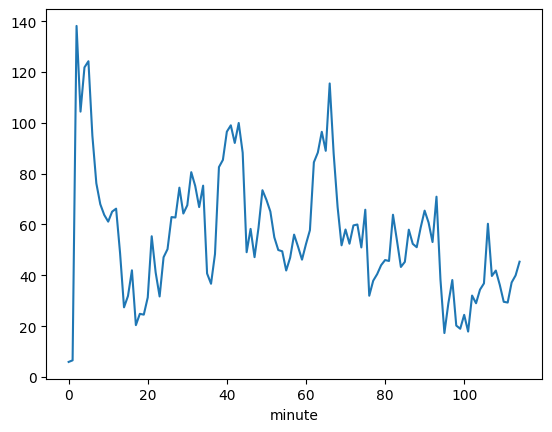

In [ ]:
film_stat('Rosencrantz_&_Guildenstern_Are_Dead', 'brightness')

### 4 комнаты

<Axes: xlabel='minute'>

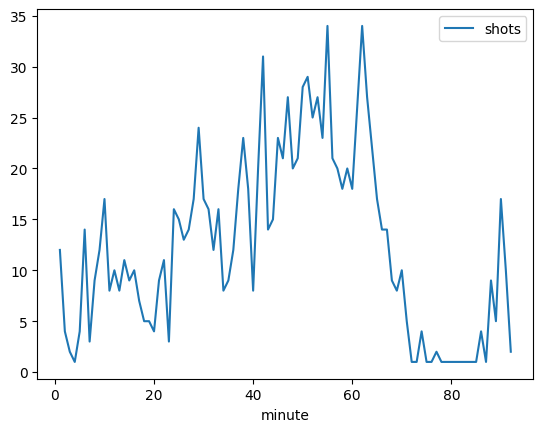

In [ ]:
film_stat('Four_Rooms', f_type='shot')

<Axes: xlabel='minute'>

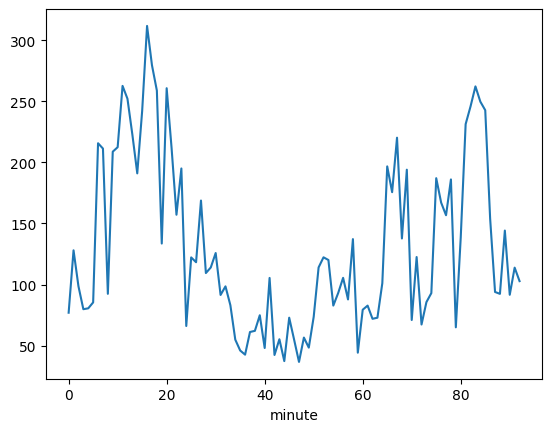

In [ ]:
film_stat('Four_Rooms', 'nobjects')

<Axes: xlabel='minute'>

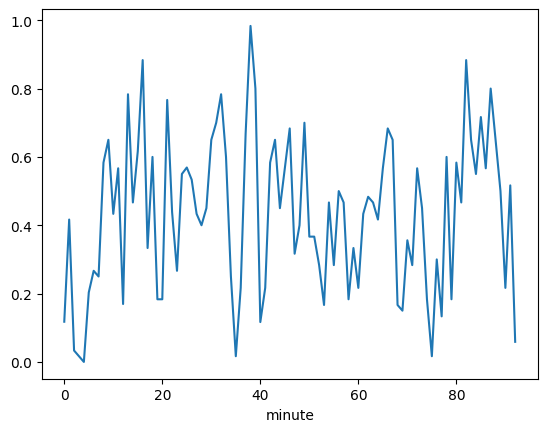

In [ ]:
film_stat('Four_Rooms', 'faces_bool')

<Axes: xlabel='minute'>

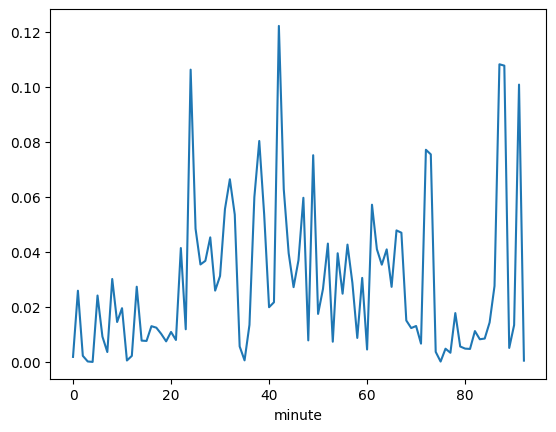

In [ ]:
film_stat('Four_Rooms', 'fsquare')

<Axes: xlabel='minute'>

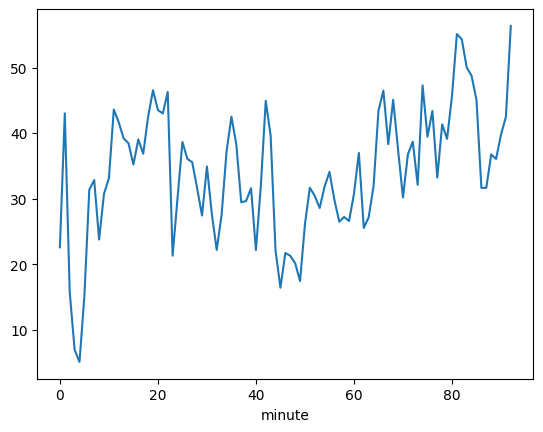

In [ ]:
film_stat('Four_Rooms', 'brightness')